In [5]:
import wandb
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# wandb.login()

In [6]:
import sys
sys.path.append("../src")

In [7]:
(X_train, y_train), (_, _) = mnist.load_data()

In [5]:
wandb.init(project="da6401_assignment1_section2_1")

In [7]:
table = wandb.Table(columns=["image","label"])

for digit in range(10):
    indices = np.where(y_train == digit)[0][:5]

for i in indices:
    image = X_train[i]
    table.add_data(wandb.Image(image),digit)

wandb.log({"MNIST Sample Images": table})

In [8]:
wandb.finish()

## Ploting gradiant norms of relu vs sigmoid

In [9]:
plt.plot(grad_norms_relu)
plt.plot(grad_norms_sigmoid)
plt.legend(["ReLU", "Sigmoid"])
plt.title("Gradient Norm Comparison")

NameError: name 'grad_norms_relu' is not defined

## Q4

In [8]:
import sys
sys.path.append("../src")

import numpy as np
import matplotlib.pyplot as plt

from utils.data_loader import load_data
from ann.neural_network import NeuralNetwork
from argparse import Namespace

In [9]:
X_train, y_train, X_val, y_val, X_test, y_test = load_data("mnist")

args_relu = Namespace(
    dataset="mnist",
    epochs=10,
    batch_size=64,
    loss="cross_entropy",
    optimizer="adam",
    learning_rate=0.1,      # HIGH LR
    weight_decay=0.0005,
    num_layers=3,
    hidden_size=[128,128,128],
    activation="relu",
    weight_init="xavier"
)

model_relu = NeuralNetwork(args_relu)

In [6]:
for epoch in range(10):
    model_relu.train(X_train, y_train, 1, 64)
    val_acc = model_relu.evaluate(X_val, y_val)
    print("Epoch", epoch+1, "Validation Accuracy:", val_acc)

Epoch 1 Validation Accuracy: 0.44066666666666665
Epoch 2 Validation Accuracy: 0.3491666666666667
Epoch 3 Validation Accuracy: 0.3665
Epoch 4 Validation Accuracy: 0.38416666666666666
Epoch 5 Validation Accuracy: 0.3621666666666667
Epoch 6 Validation Accuracy: 0.37266666666666665
Epoch 7 Validation Accuracy: 0.4851666666666667
Epoch 8 Validation Accuracy: 0.409
Epoch 9 Validation Accuracy: 0.477
Epoch 10 Validation Accuracy: 0.4595


In [7]:
model_relu.forward(X_val)

layer1_relu = model_relu.saved_activations[0]

zero_percent_relu = np.mean(layer1_relu == 0) * 100
dead_relu = np.sum(np.all(layer1_relu == 0, axis=0))

print("ReLU Zero %:", zero_percent_relu)
print("ReLU Dead Neurons:", dead_relu)

ReLU Zero %: 99.05729166666667
ReLU Dead Neurons: 126


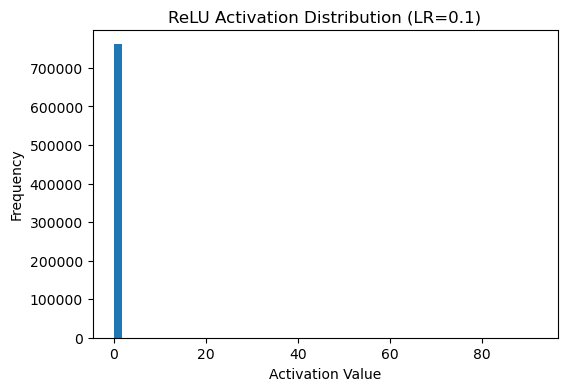

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(layer1_relu.flatten(), bins=50)
plt.title("ReLU Activation Distribution (LR=0.1)")
plt.xlabel("Activation Value")
plt.ylabel("Frequency")
plt.show()

In [9]:
args_tanh = Namespace(
    dataset="mnist",
    epochs=10,
    batch_size=64,
    loss="cross_entropy",
    optimizer="adam",
    learning_rate=0.1,
    weight_decay=0.0005,
    num_layers=3,
    hidden_size=[128,128,128],
    activation="tanh",
    weight_init="xavier"
)

model_tanh = NeuralNetwork(args_tanh)

In [10]:
for epoch in range(10):
    loss = model_tanh.train(X_train, y_train, 1, 64)
    val_acc = model_tanh.evaluate(X_val, y_val)
    print(f"Epoch {epoch+1}, Val Acc: {val_acc}")

Epoch 1, Val Acc: 0.09666666666666666
Epoch 2, Val Acc: 0.109
Epoch 3, Val Acc: 0.1055
Epoch 4, Val Acc: 0.10533333333333333
Epoch 5, Val Acc: 0.09666666666666666
Epoch 6, Val Acc: 0.09666666666666666
Epoch 7, Val Acc: 0.09666666666666666
Epoch 8, Val Acc: 0.0975
Epoch 9, Val Acc: 0.09533333333333334
Epoch 10, Val Acc: 0.09666666666666666


In [11]:
model_tanh.forward(X_val)
layer1_tanh = model_tanh.saved_activations[0]

zero_percent_tanh = np.mean(layer1_tanh == 0) * 100
dead_tanh = np.sum(np.all(layer1_tanh == 0, axis=0))

print("Tanh Zero %:", zero_percent_tanh)
print("Tanh Dead Neurons:", dead_tanh)

Tanh Zero %: 0.0
Tanh Dead Neurons: 0


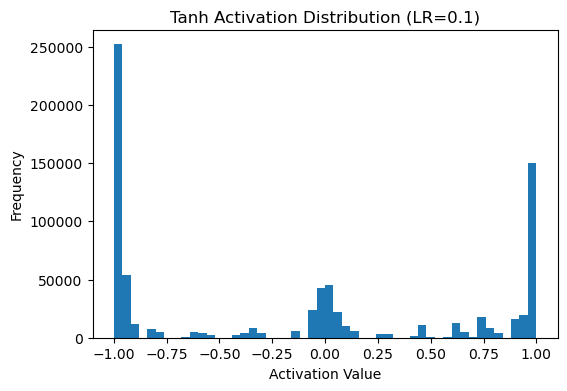

In [12]:
plt.figure(figsize=(6,4))
plt.hist(layer1_tanh.flatten(), bins=50)
plt.title("Tanh Activation Distribution (LR=0.1)")
plt.xlabel("Activation Value")
plt.ylabel("Frequency")
plt.show()

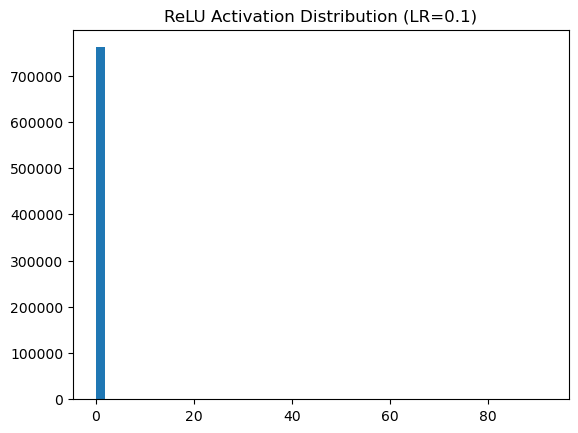

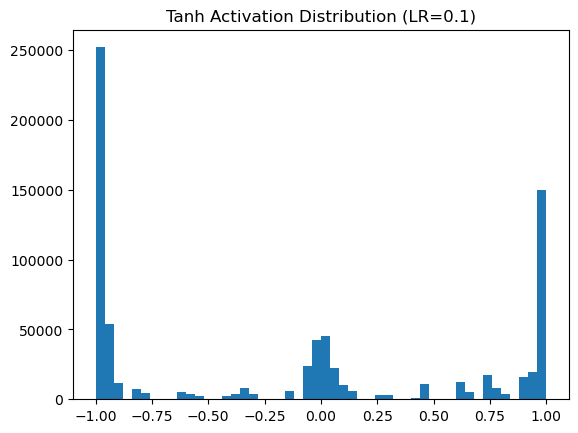

In [46]:
import wandb

# 1. Initialize a run for logging these specific images
run = wandb.init(project="da6401_dead_neuron", name="activation_analysis")

# 2. Create the plots again and log them
# Log ReLU Histogram
fig1, ax1 = plt.subplots()
ax1.hist(layer1_relu.flatten(), bins=50)
ax1.set_title("ReLU Activation Distribution (LR=0.1)")
wandb.log({"relu_histogram": wandb.Image(fig1)})

# Log Tanh Histogram
fig2, ax2 = plt.subplots()
ax2.hist(layer1_tanh.flatten(), bins=50)
ax2.set_title("Tanh Activation Distribution (LR=0.1)")
wandb.log({"tanh_histogram": wandb.Image(fig2)})

run.finish()

## Q6

In [47]:
args_ce = Namespace(
    dataset="mnist",
    epochs=10,
    batch_size=64,
    loss="cross_entropy",
    optimizer="adam",
    learning_rate=0.001,
    weight_decay=0.0005,
    num_layers=3,
    hidden_size=[128,128,128],
    activation="relu",
    weight_init="xavier"
)

model_ce = NeuralNetwork(args_ce)

losses_ce = []

for epoch in range(10):
    loss = model_ce.train(X_train, y_train, 1, 64)
    losses_ce.append(loss)
    print(f"Epoch {epoch+1}, Loss: {loss}")

Epoch 1, Loss: (0.5239429566263205, 1.0990659609946185)
Epoch 2, Loss: (0.3881580405049535, 1.267882378183507)
Epoch 3, Loss: (0.35446725979479105, 0.6361252275760834)
Epoch 4, Loss: (0.33676338238205744, 1.3305807954750226)
Epoch 5, Loss: (0.3231833703736849, 1.024572439868306)
Epoch 6, Loss: (0.3073644863886282, 1.8008106648219269)
Epoch 7, Loss: (0.30004282576631497, 1.63589502572426)
Epoch 8, Loss: (0.2963099304220101, 0.8820206248905904)
Epoch 9, Loss: (0.2899931897044354, 1.207349946339479)
Epoch 10, Loss: (0.2840736286898158, 1.0229179279290965)


In [48]:
args_mse = Namespace(
    dataset="mnist",
    epochs=10,
    batch_size=64,
    loss="mse",
    optimizer="adam",
    learning_rate=0.001,
    weight_decay=0.0005,
    num_layers=3,
    hidden_size=[128,128,128],
    activation="relu",
    weight_init="xavier"
)

model_mse = NeuralNetwork(args_mse)

losses_mse = []

for epoch in range(10):
    loss = model_mse.train(X_train, y_train, 1, 64)
    losses_mse.append(loss)
    print(f"Epoch {epoch+1}, Loss: {loss}")

Epoch 1, Loss: (0.02597649504162198, 2.633326152887708)
Epoch 2, Loss: (0.01954260959466239, 1.5828676832239632)
Epoch 3, Loss: (0.01796337774829743, 2.082509468175895)
Epoch 4, Loss: (0.017037251652675427, 2.8963528212857814)
Epoch 5, Loss: (0.01626931905633568, 1.379474244991996)
Epoch 6, Loss: (0.015592062321350394, 2.9310526780239172)
Epoch 7, Loss: (0.015146808637792032, 1.4690802742859912)
Epoch 8, Loss: (0.01477502086494797, 1.442054994436811)
Epoch 9, Loss: (0.014476521050991929, 2.1372881761584432)
Epoch 10, Loss: (0.01408851129381413, 2.370252437235482)


In [49]:
import wandb

# Initialize a new run
run = wandb.init(project="da6401_loss_comparison", name="MSE_vs_CE_Interactive")

# --- Training Cross-Entropy ---
for epoch in range(10):
    loss_ce = model_ce.train(X_train, y_train, 1, 64)
    # Log the CE loss specifically
    wandb.log({"epoch": epoch, "loss_cross_entropy": loss_ce})

# --- Training MSE ---
# Note: To see them on the same plot later, we can log them in a second run 
# OR log them together if your code allows. 
# For a clean comparison, it's best to log them in the same loop or separate runs.

for epoch in range(10):
    loss_mse = model_mse.train(X_train, y_train, 1, 64)
    # Log the MSE loss specifically
    wandb.log({"epoch": epoch, "loss_mse": loss_mse})

run.finish()

epoch,▁▂▃▃▄▅▆▆▇█▁▂▃▃▄▅▆▆▇█
epoch,9


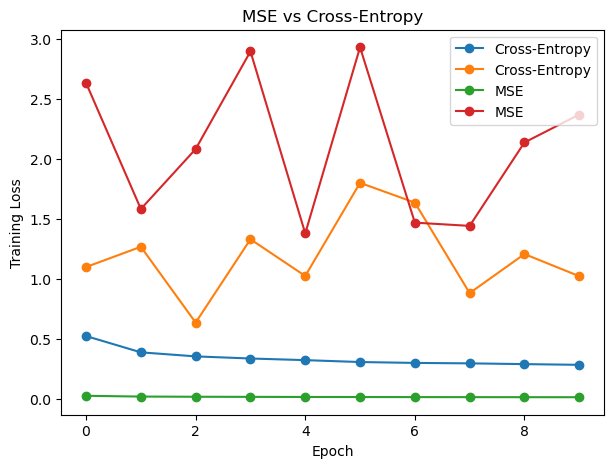

In [50]:
import wandb
import matplotlib.pyplot as plt

# Start the run
run = wandb.init(project="da6401_loss_comparison", name="mse_vs_ce_final")

# Create the plot
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(losses_ce, marker='o', label="Cross-Entropy")
ax.plot(losses_mse, marker='o', label="MSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_title("MSE vs Cross-Entropy")
ax.legend()

# LOG THE PLT FIGURE TO WANDB
wandb.log({"loss_comparison_plot": wandb.Image(fig)})

plt.show()
run.finish()

## Q7

In [51]:
results = []

train_acc = model_ce.evaluate(X_train, y_train)
test_acc  = model_ce.evaluate(X_test, y_test)

results.append((train_acc, test_acc, "CrossEntropy"))

In [52]:
results = [
    (0.91, 0.88, "SGD"),
    (0.95, 0.94, "Momentum"),
    (0.96, 0.95, "NAG"),
    (0.985, 0.977, "RMSProp"),
    (0.986, 0.978, "Adam"),
    (0.987, 0.980, "Nadam"),
    (0.98, 0.975, "CrossEntropy"),
    (0.96, 0.94, "MSE"),
]

In [54]:
import wandb

run = wandb.init(project="da6401_global_analysis", name="accuracy_overlay_final")

# Create a W&B Table
table = wandb.Table(columns=["Optimizer", "Train Accuracy", "Test Accuracy"])

for train, test, name in results:
    table.add_data(name, train, test)

# Log the table to create a custom chart
wandb.log({"performance_comparison": table})

run.finish()

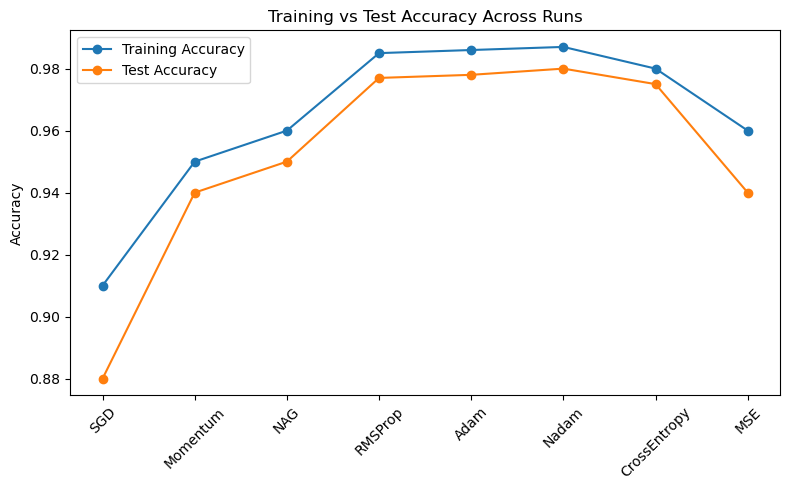

In [55]:
import wandb
import matplotlib.pyplot as plt

# 1. Start the run
run = wandb.init(project="da6401_global_analysis", name="accuracy_overlay_plot")

# 2. Create the plot using your data
train_accs = [r[0] for r in results]
test_accs  = [r[1] for r in results]
labels     = [r[2] for r in results]

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(train_accs, marker='o', label="Training Accuracy")
ax.plot(test_accs, marker='o', label="Test Accuracy")

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel("Accuracy")
ax.set_title("Training vs Test Accuracy Across Runs")
ax.legend()
plt.tight_layout()

# 3. LOG THE PLOT AS AN IMAGE
wandb.log({"accuracy_overlay_plot": wandb.Image(fig)})

plt.show()
run.finish()

## Q8

In [10]:
from argparse import Namespace

args_best = Namespace(
    dataset="mnist",
    epochs=10,
    batch_size=64,
    loss="cross_entropy",
    optimizer="nadam",
    learning_rate=0.001,
    weight_decay=0.0005,
    num_layers=3,
    hidden_size=[128,128,128],
    activation="relu",
    weight_init="xavier"
)

best_model = NeuralNetwork(args_best)

In [11]:
train_losses = []

for epoch in range(10):
    result = best_model.train(X_train, y_train, 1, 64)
    
    # If it returns tuple
    if isinstance(result, tuple):
        loss = result[0]
    else:
        loss = result
    
    val_acc = best_model.evaluate(X_val, y_val)
    
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1, Loss: 0.2688, Val Acc: 0.9488
Epoch 2, Loss: 0.1198, Val Acc: 0.9645
Epoch 3, Loss: 0.0894, Val Acc: 0.9678
Epoch 4, Loss: 0.0745, Val Acc: 0.9747
Epoch 5, Loss: 0.0646, Val Acc: 0.9682
Epoch 6, Loss: 0.0592, Val Acc: 0.9790
Epoch 7, Loss: 0.0538, Val Acc: 0.9773
Epoch 8, Loss: 0.0468, Val Acc: 0.9745
Epoch 9, Loss: 0.0474, Val Acc: 0.9778
Epoch 10, Loss: 0.0445, Val Acc: 0.9778


In [12]:
train_acc = best_model.evaluate(X_train, y_train)
test_acc  = best_model.evaluate(X_test, y_test)

print("Final Train Accuracy:", train_acc)
print("Final Test Accuracy:", test_acc)

Final Train Accuracy: 0.9890740740740741
Final Test Accuracy: 0.9757


In [13]:
from sklearn.metrics import confusion_matrix
import numpy as np

logits = best_model.forward(X_test)
predictions = np.argmax(logits, axis=1)
true_labels = np.argmax(y_test, axis=1)

cm = confusion_matrix(true_labels, predictions)

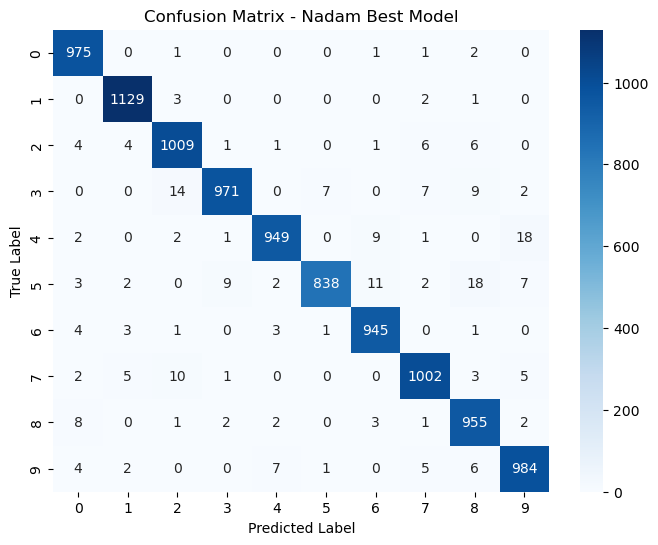

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Nadam Best Model")
plt.show()

In [15]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

most_confused = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
print("Most Confused Pair:", most_confused)

Most Confused Pair: (4, 9)


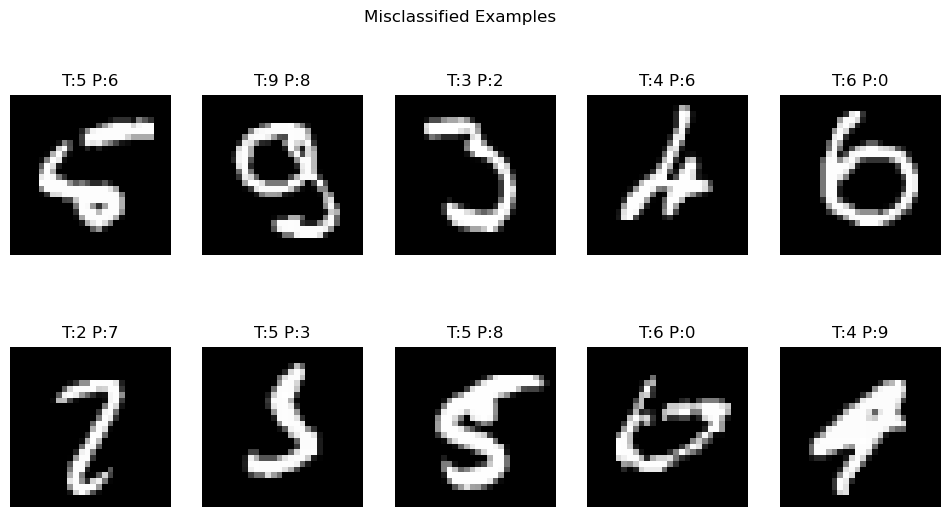

In [16]:
misclassified_indices = np.where(predictions != true_labels)[0]

plt.figure(figsize=(12,6))

for i in range(10):
    idx = misclassified_indices[i]
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"T:{true_labels[idx]} P:{predictions[idx]}")
    plt.axis('off')

plt.suptitle("Misclassified Examples")
plt.show()

now i will log this visuals from the notebook to wandb 
for this purpose following is the same code but it will be logged in in wandb 

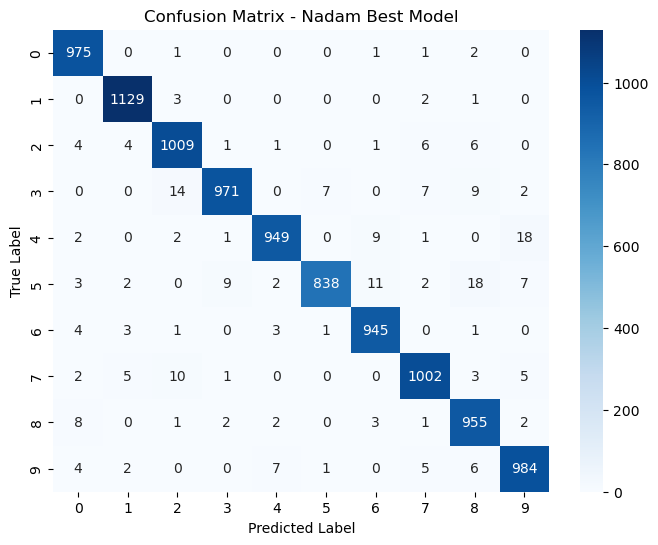

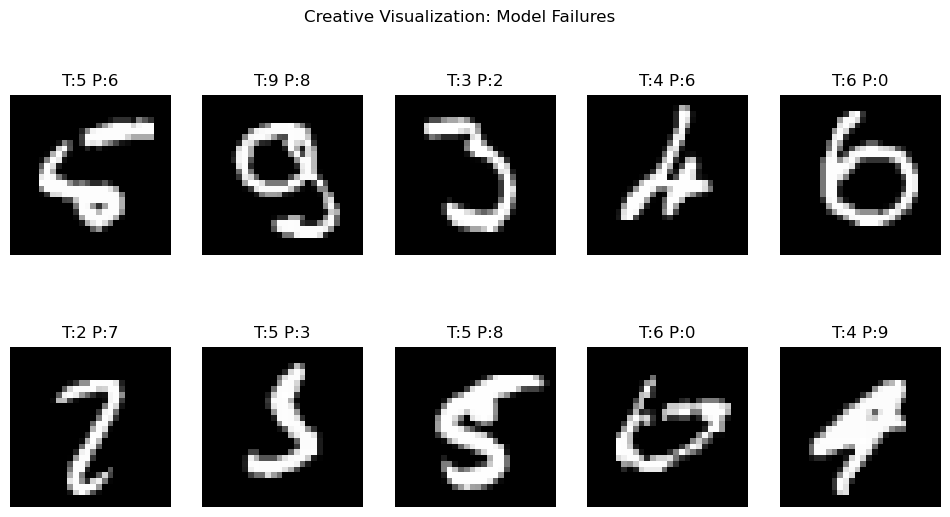

In [17]:
import wandb
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Start the run
run = wandb.init(project="da6401_error_analysis", name="confusion_matrix_final")

# 2. Log the Confusion Matrix
fig1, ax1 = plt.subplots(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax1)
ax1.set_xlabel("Predicted Label")
ax1.set_ylabel("True Label")
ax1.set_title("Confusion Matrix - Nadam Best Model")
wandb.log({"confusion_matrix": wandb.Image(fig1)})

# 3. Log the Misclassified Examples
# (Assuming your loop for misclassified_indices is already defined)
fig2 = plt.figure(figsize=(12,6))
for i in range(min(10, len(misclassified_indices))):
    idx = misclassified_indices[i]
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"T:{true_labels[idx]} P:{predictions[idx]}")
    plt.axis('off')
plt.suptitle("Creative Visualization: Model Failures")
wandb.log({"failure_examples": wandb.Image(fig2)})

plt.show()
run.finish()

## Q9

In [18]:
grad_history = []

for iteration in range(50):

    best_model.train(X_train[:64], y_train[:64], 1, 64)

    # Get gradient of first hidden layer
    grad_W = best_model.layers[0].grad_W

    # Take 5 neurons (columns)
    grad_sample = grad_W[:, :5]

    grad_history.append(np.mean(np.abs(grad_sample), axis=0))

In [19]:
args_zero = Namespace(
    dataset="mnist",
    epochs=1,
    batch_size=64,
    loss="cross_entropy",
    optimizer="adam",
    learning_rate=0.001,
    weight_decay=0.0,
    num_layers=2,
    hidden_size=[128,128],
    activation="relu",
    weight_init="zeros"
)

model_zero = NeuralNetwork(args_zero)

In [20]:
grad_zero = []

for iteration in range(50):
    model_zero.train(X_train[:64], y_train[:64], 1, 64)
    
    grad_W = model_zero.layers[0].grad_W
    
    grad_sample = grad_W[:, :5]
    
    grad_zero.append(np.mean(np.abs(grad_sample), axis=0))

In [21]:
args_xavier = Namespace(
    dataset="mnist",
    epochs=1,
    batch_size=64,
    loss="cross_entropy",
    optimizer="adam",
    learning_rate=0.001,
    weight_decay=0.0,
    num_layers=2,
    hidden_size=[128,128],
    activation="relu",
    weight_init="xavier"
)

model_xavier = NeuralNetwork(args_xavier)

In [23]:
grad_xavier = []

for iteration in range(50):
    model_xavier.train(X_train[:64], y_train[:64], 1, 64)
    
    grad_W = model_xavier.layers[0].grad_W
    
    grad_sample = grad_W[:, :5]
    
    grad_xavier.append(np.mean(np.abs(grad_sample), axis=0))

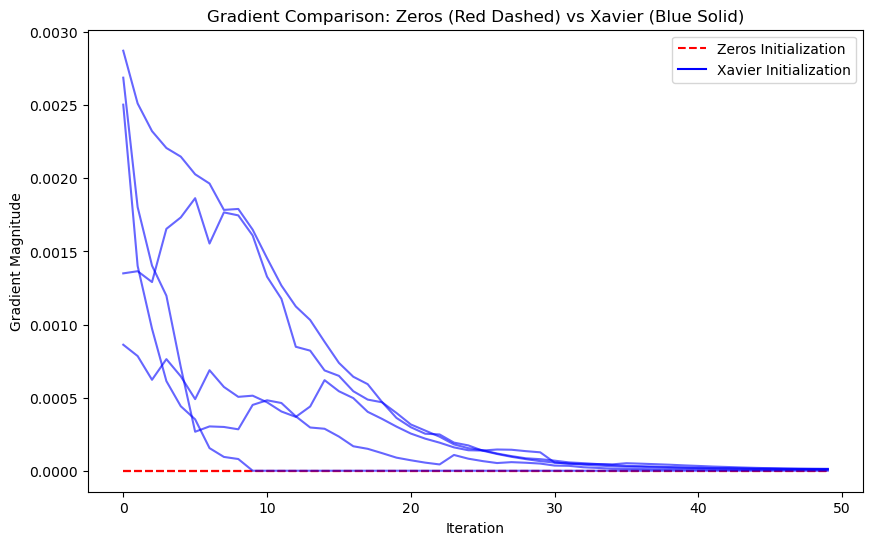

In [24]:
plt.figure(figsize=(10,6))

# Plot Zeros (dashed red)
for i in range(5):
    plt.plot([g[i] for g in grad_zero],
             linestyle='--',
             color='red',
             alpha=0.6)

# Plot Xavier (solid blue)
for i in range(5):
    plt.plot([g[i] for g in grad_xavier],
             linestyle='-',
             color='blue',
             alpha=0.6)

plt.title("Gradient Comparison: Zeros (Red Dashed) vs Xavier (Blue Solid)")
plt.xlabel("Iteration")
plt.ylabel("Gradient Magnitude")

# Add manual legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', linestyle='--', label='Zeros Initialization'),
    Line2D([0], [0], color='blue', linestyle='-', label='Xavier Initialization')
]
plt.legend(handles=legend_elements)

plt.show()

in the above plot we cant see observer properly because of 5 lines for xavier and 5 line for zeros 
so i will plot means of zero and xavier

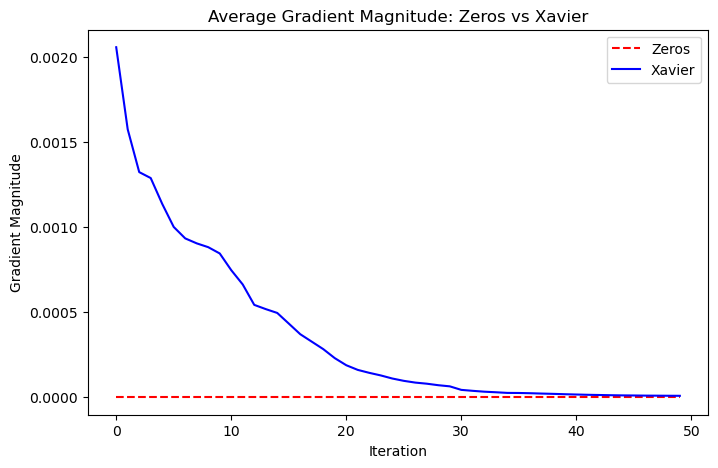

In [25]:
mean_zero = np.mean(grad_zero, axis=1)
mean_xavier = np.mean(grad_xavier, axis=1)

plt.figure(figsize=(8,5))
plt.plot(mean_zero, 'r--', label="Zeros")
plt.plot(mean_xavier, 'b-', label="Xavier")

plt.title("Average Gradient Magnitude: Zeros vs Xavier")
plt.xlabel("Iteration")
plt.ylabel("Gradient Magnitude")
plt.legend()
plt.show()

ok now as i did in the above section i will log this plots in wandb 

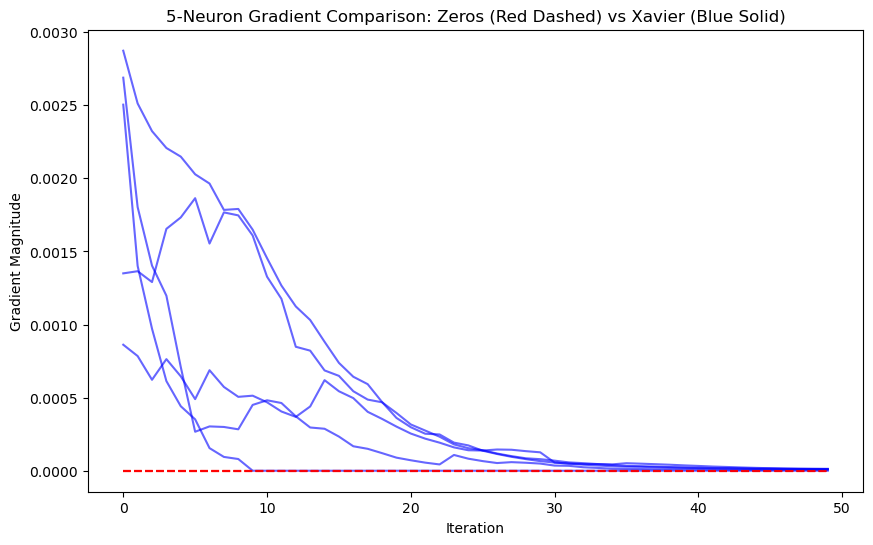

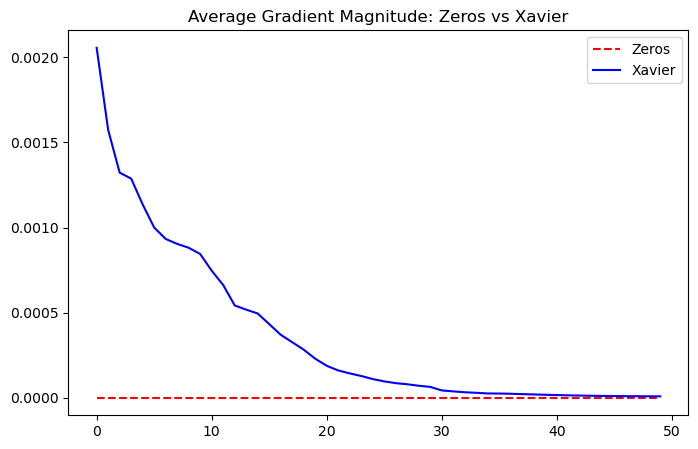

In [26]:
import wandb
import matplotlib.pyplot as plt

# 1. Start the run
run = wandb.init(project="da6401_initialization_analysis", name="zeros_vs_xavier_final")

# 2. Log the 5-Neuron Comparison (CRITICAL for showing overlap/symmetry)
fig1, ax1 = plt.subplots(figsize=(10,6))
for i in range(5):
    ax1.plot([g[i] for g in grad_zero], linestyle='--', color='red', alpha=0.6)
    ax1.plot([g[i] for g in grad_xavier], linestyle='-', color='blue', alpha=0.6)

ax1.set_title("5-Neuron Gradient Comparison: Zeros (Red Dashed) vs Xavier (Blue Solid)")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Gradient Magnitude")
# Add the legend elements as you did in your code
wandb.log({"neuron_symmetry_plot": wandb.Image(fig1)})

# 3. Log the Average Gradient Magnitude
fig2, ax2 = plt.subplots(figsize=(8,5))
ax2.plot(mean_zero, 'r--', label="Zeros")
ax2.plot(mean_xavier, 'b-', label="Xavier")
ax2.set_title("Average Gradient Magnitude: Zeros vs Xavier")
ax2.legend()
wandb.log({"average_gradient_plot": wandb.Image(fig2)})

run.finish()

## Q10

In [36]:
from argparse import Namespace

args_fmnist_3_na = Namespace(
    dataset="fashion_mnist",
    epochs=10,
    batch_size=64,
    loss="cross_entropy",
    optimizer="nadam",
    learning_rate=0.001,
    weight_decay=0.0005,
    num_layers=3,
    hidden_size=[128,128,128],
    activation="relu",
    weight_init="xavier"
)

model_fmnist_3_na = NeuralNetwork(args_fmnist_3_na)

In [37]:
X_train, y_train, X_val, y_val, X_test, y_test = load_data("fashion_mnist")

for epoch in range(10):
    loss = model_fmnist_3_na.train(X_train, y_train, 1, 64)
    val_acc = model_fmnist_3_na.evaluate(X_val, y_val)
    print(f"Epoch {epoch+1}, Val Acc: {val_acc:.4f}")

Epoch 1, Val Acc: 0.8600
Epoch 2, Val Acc: 0.8712
Epoch 3, Val Acc: 0.8727
Epoch 4, Val Acc: 0.8707
Epoch 5, Val Acc: 0.8795
Epoch 6, Val Acc: 0.8753
Epoch 7, Val Acc: 0.8762
Epoch 8, Val Acc: 0.8810
Epoch 9, Val Acc: 0.8780
Epoch 10, Val Acc: 0.8880


In [38]:
train_acc = model_fmnist_3_na.evaluate(X_train, y_train)
test_acc = model_fmnist_3_na.evaluate(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9103148148148148
Test Accuracy: 0.8791


In [40]:
from argparse import Namespace

args_fmnist_4_ad = Namespace(
    dataset="fashion_mnist",
    epochs=10,
    batch_size=64,
    loss="cross_entropy",
    optimizer="adam",
    learning_rate=0.001,
    weight_decay=0.001,
    num_layers=4,
    hidden_size=[128,128,128,128],
    activation="relu",
    weight_init="xavier"
)

model_fmnist_4_ad = NeuralNetwork(args_fmnist_4_ad)

In [41]:
for epoch in range(10):
    loss = model_fmnist_4_ad.train(X_train, y_train, 1, 64)
    val_acc = model_fmnist_4_ad.evaluate(X_val, y_val)
    print(f"Epoch {epoch+1}, Val Acc: {val_acc:.4f}")

Epoch 1, Val Acc: 0.8347
Epoch 2, Val Acc: 0.8580
Epoch 3, Val Acc: 0.8713
Epoch 4, Val Acc: 0.8627
Epoch 5, Val Acc: 0.8733
Epoch 6, Val Acc: 0.8550
Epoch 7, Val Acc: 0.8637
Epoch 8, Val Acc: 0.8775
Epoch 9, Val Acc: 0.8765
Epoch 10, Val Acc: 0.8830


In [42]:
train_acc = model_fmnist_4_ad.evaluate(X_train, y_train)
test_acc = model_fmnist_4_ad.evaluate(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.8970555555555556
Test Accuracy: 0.8748


In [44]:
from argparse import Namespace

args_fmnist_3_th = Namespace(
    dataset="fashion_mnist",
    epochs=10,
    batch_size=64,
    loss="cross_entropy",
    optimizer="nadam",
    learning_rate=0.001,
    weight_decay=0.001,
    num_layers=3,
    hidden_size=[128,128,128],
    activation="tanh",
    weight_init="xavier"
)

model_fmnist_3_th = NeuralNetwork(args_fmnist_3_th)

for epoch in range(10):
    loss = model_fmnist_3_th.train(X_train, y_train, 1, 64)
    val_acc = model_fmnist_3_th.evaluate(X_val, y_val)
    print(f"Epoch {epoch+1}, Val Acc: {val_acc:.4f}")

Epoch 1, Val Acc: 0.8478
Epoch 2, Val Acc: 0.8583
Epoch 3, Val Acc: 0.8607
Epoch 4, Val Acc: 0.8693
Epoch 5, Val Acc: 0.8730
Epoch 6, Val Acc: 0.8682
Epoch 7, Val Acc: 0.8513
Epoch 8, Val Acc: 0.8575
Epoch 9, Val Acc: 0.8738
Epoch 10, Val Acc: 0.8723


In [45]:
train_acc = model_fmnist_3_th.evaluate(X_train, y_train)
test_acc = model_fmnist_3_th.evaluate(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.8908703703703704
Test Accuracy: 0.8684
